In [1]:
# Runtime setup for Colab or Vast.AI (run this cell first)
import importlib.util
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path


def install_if_needed(
    module_name, package_spec, distribution_name=None, minimum_major=None
):
    distribution_name = distribution_name or package_spec.split(">=")[0]
    needs_install = importlib.util.find_spec(module_name) is None

    if minimum_major is not None and not needs_install:
        try:
            installed_major = int(version(distribution_name).split(".")[0])
            needs_install = installed_major < minimum_major
        except (PackageNotFoundError, ValueError):
            needs_install = True

    if needs_install:
        print(f"Installing {package_spec} ...")
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", package_spec]
            )
        except Exception as exc:
            raise RuntimeError(
                f"Failed to install {package_spec}. Restart the runtime/kernel, then rerun this cell."
            ) from exc


install_if_needed("imblearn", "imbalanced-learn", distribution_name="imbalanced-learn")
install_if_needed(
    "xgboost", "xgboost>=2.0.0", distribution_name="xgboost", minimum_major=2
)
install_if_needed("seaborn", "seaborn")
install_if_needed("joblib", "joblib")

try:
    from google.colab import drive

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    try:
        drive.mount("/content/drive", force_remount=False, timeout_ms=300000)
    except Exception as exc:
        raise RuntimeError(
            "Failed to mount Google Drive. Make sure Drive permission is granted, then rerun this cell."
        ) from exc
else:
    print("Not running in Google Colab; Google Drive mount skipped.")

IN_VASTAI = not IN_COLAB and Path("/workspace").exists()
if IN_VASTAI:
    print("Vast.AI-style /workspace directory detected.")

Installing imbalanced-learn ...


Installing xgboost>=2.0.0 ...


Installing seaborn ...
Not running in Google Colab; Google Drive mount skipped.
Vast.AI-style /workspace directory detected.


In [2]:
# Package
import gc
import glob
import json
import os
import shutil
import subprocess
import sys
import time
import traceback
from collections import Counter
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, train_test_split

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    log_loss,
)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Checkpoint, resume, and error logging
PIPELINE_VERSION = "pipeline_flowchart_v1"
IN_COLAB = globals().get("IN_COLAB", False)
IN_VASTAI = globals().get("IN_VASTAI", (not IN_COLAB and Path("/workspace").exists()))
TARGET_GPU_KEYWORD = os.environ.get("NIDS_TARGET_GPU_KEYWORD", "RTX 4090")
REQUIRE_TARGET_GPU = os.environ.get(
    "NIDS_REQUIRE_TARGET_GPU", "1"
).strip().lower() not in {"0", "false", "no"}

if IN_COLAB:
    DEFAULT_DATASET_GLOB = "/content/drive/MyDrive/NIDS/datasets/**/*.csv"
elif IN_VASTAI:
    DEFAULT_DATASET_GLOB = "/workspace/NIDS/datasets/**/*.csv"
else:
    DEFAULT_DATASET_GLOB = "datasets/**/*.csv"

DATASET_GLOB = os.environ.get("NIDS_DATASET_GLOB", DEFAULT_DATASET_GLOB)
RUN_MODE = (
    os.environ.get("NIDS_RUN_MODE", "full").strip().lower()
)  # Use 'fast' for iteration, 'full' for final research-quality output.
FORCE_RECOMPUTE = (
    False  # Set to True to recompute all stages and overwrite checkpoints.
)
CLEAR_CHECKPOINTS = (
    False  # Set to True once to remove old checkpoints for the active RUN_MODE.
)

MODE_CONFIGS = {
    "fast": {
        "n_splits": 5,
        "run_feature_importance": True,
        "feature_importance_max_samples": 20_000,
        "feature_importance_n_repeats": 2,
        "validation_models": {
            "rf_n_estimators": 100,
            "rf_max_depth": 16,
            "xgb_n_estimators": 100,
            "xgb_max_depth": 6,
            "dt_max_depth": 16,
            "stacking_cv": 3,
        },
        "final_models": {
            "rf_n_estimators": 100,
            "rf_max_depth": 16,
            "xgb_n_estimators": 100,
            "xgb_max_depth": 6,
            "dt_max_depth": 16,
            "stacking_cv": 3,
        },
    },
    "full": {
        "n_splits": 5,
        "run_feature_importance": True,
        "feature_importance_max_samples": 50_000,
        "feature_importance_n_repeats": 3,
        "validation_models": {
            "rf_n_estimators": 300,
            "rf_max_depth": 20,
            "xgb_n_estimators": 300,
            "xgb_max_depth": 8,
            "dt_max_depth": 20,
            "stacking_cv": 5,
        },
        "final_models": {
            "rf_n_estimators": 300,
            "rf_max_depth": 20,
            "xgb_n_estimators": 300,
            "xgb_max_depth": 8,
            "dt_max_depth": 20,
            "stacking_cv": 5,
        },
    },
}

if RUN_MODE not in MODE_CONFIGS:
    raise ValueError(
        f"RUN_MODE must be one of {sorted(MODE_CONFIGS)}, got {RUN_MODE!r}"
    )

RUN_CONFIG = MODE_CONFIGS[RUN_MODE]

PIPELINE_OUTPUT_DIR_OVERRIDE = os.environ.get("NIDS_PIPELINE_OUTPUT_DIR")
if PIPELINE_OUTPUT_DIR_OVERRIDE:
    PIPELINE_OUTPUT_DIR = Path(PIPELINE_OUTPUT_DIR_OVERRIDE)
elif IN_COLAB:
    PIPELINE_OUTPUT_DIR = Path("/content/drive/MyDrive/NIDS/pipeline")
elif IN_VASTAI:
    PIPELINE_OUTPUT_DIR = Path("/workspace/NIDS/pipeline")
else:
    PIPELINE_OUTPUT_DIR = Path("pipeline_outputs")

CHECKPOINT_DIR = PIPELINE_OUTPUT_DIR / f"pipeline_{RUN_MODE}_checkpoints"
RESULTS_DIR = PIPELINE_OUTPUT_DIR / f"results_cv_{RUN_MODE}"

ERROR_LOG_DIR = PIPELINE_OUTPUT_DIR / "error_logs"
PIPELINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ERROR_LOG_DIR.mkdir(parents=True, exist_ok=True)
STAGE_STATUS = {}


def _timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def _stage_path(stage_name):
    safe_name = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in stage_name)
    return CHECKPOINT_DIR / f"{safe_name}.joblib"


def write_error_report(stage_name, exc):
    ERROR_LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = ERROR_LOG_DIR / f"{_timestamp()}_{stage_name}.log"
    report = {
        "stage": stage_name,
        "pipeline_version": PIPELINE_VERSION,
        "run_mode": RUN_MODE,
        "error_type": type(exc).__name__,
        "error_message": str(exc),
        "traceback": traceback.format_exc(),
    }
    log_path.write_text(
        json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    print(f"Error log saved to: {log_path}")
    return log_path


def checkpoint_exists(stage_name):
    return _stage_path(stage_name).exists()


def _validate_stage_objects(stage_name, objects, expected_keys=None):
    if not isinstance(objects, dict):
        raise TypeError(
            f"Stage '{stage_name}' harus mengembalikan dict, bukan {type(objects).__name__}."
        )
    if expected_keys:
        missing = [key for key in expected_keys if key not in objects]
        if missing:
            raise KeyError(
                f"Checkpoint stage '{stage_name}' is missing required keys: {missing}"
            )


def save_stage(stage_name, objects, expected_keys=None):
    _validate_stage_objects(stage_name, objects, expected_keys)
    path = _stage_path(stage_name)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    payload = {
        "pipeline_version": PIPELINE_VERSION,
        "run_mode": RUN_MODE,
        "run_config": RUN_CONFIG,
        "stage_name": stage_name,
        "saved_at": _timestamp(),
        "objects": objects,
    }
    joblib.dump(payload, tmp_path, compress=3)
    os.replace(tmp_path, path)
    print(f"Checkpoint saved: {path}")


def load_stage(stage_name, expected_keys=None):
    path = _stage_path(stage_name)
    payload = joblib.load(path)
    if payload.get("pipeline_version") != PIPELINE_VERSION:
        raise ValueError(
            f"Checkpoint version for '{stage_name}' differs: {payload.get('pipeline_version')} != {PIPELINE_VERSION}"
        )
    if payload.get("run_mode") != RUN_MODE:
        raise ValueError(
            f"Checkpoint run mode for '{stage_name}' differs: {payload.get('run_mode')} != {RUN_MODE}"
        )
    if payload.get("run_config") != RUN_CONFIG:
        raise ValueError(
            f"Checkpoint run config for '{stage_name}' differs from the active RUN_CONFIG."
        )
    objects = payload.get("objects")
    _validate_stage_objects(stage_name, objects, expected_keys)
    return objects


def restore_stage(stage_name, expected_keys=None):
    objects = load_stage(stage_name, expected_keys=expected_keys)
    globals().update(objects)
    STAGE_STATUS[stage_name] = "loaded"
    print(f"Resuming from checkpoint: {stage_name}")
    return objects


def _try_restore_stage(stage_name, expected_keys=None):
    path = _stage_path(stage_name)
    if not path.exists():
        return None
    try:
        return restore_stage(stage_name, expected_keys=expected_keys)
    except Exception as exc:
        corrupt_path = path.with_name(
            f"{path.stem}.corrupt_{_timestamp()}{path.suffix}"
        )
        try:
            path.rename(corrupt_path)
            print(f"Corrupt/incompatible checkpoint moved to: {corrupt_path}")
        except Exception:
            print(f"Corrupt/incompatible checkpoint could not be moved: {path}")
        print(f"Checkpoint '{stage_name}' will be recomputed. Reason: {exc}")
        return None


def run_or_load_stage(stage_name, stage_fn, expected_keys=None, force=None):
    force = FORCE_RECOMPUTE if force is None else force

    if not force:
        objects = _try_restore_stage(stage_name, expected_keys=expected_keys)
        if objects is not None:
            return objects

    print(f"Running stage: {stage_name}")
    try:
        objects = stage_fn()
        _validate_stage_objects(stage_name, objects, expected_keys)
        globals().update(objects)
        save_stage(stage_name, objects, expected_keys=expected_keys)
        STAGE_STATUS[stage_name] = "completed"
        gc.collect()
        return objects
    except Exception as exc:
        log_path = write_error_report(stage_name, exc)
        raise RuntimeError(
            f"Stage '{stage_name}' failed. Fix the error cause, then rerun from the top. "
            f"Stages with existing checkpoints will resume automatically. Log: {log_path}"
        ) from exc


if CLEAR_CHECKPOINTS:
    for checkpoint_file in CHECKPOINT_DIR.glob("*.joblib"):
        checkpoint_file.unlink()
    print(f"Old checkpoints removed from: {CHECKPOINT_DIR}")

print(f"Run mode: {RUN_MODE}")
print(f"Dataset glob: {DATASET_GLOB}")
print(f"Target GPU: {TARGET_GPU_KEYWORD} (required: {REQUIRE_TARGET_GPU})")
print(f"Mode config: {json.dumps(RUN_CONFIG, indent=2)}")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")
print(f"Result directory: {RESULTS_DIR}")

Run mode: full
Dataset glob: /workspace/NIDS/datasets/**/*.csv
Target GPU: RTX 4090 (required: True)
Mode config: {
  "n_splits": 5,
  "run_feature_importance": true,
  "feature_importance_max_samples": 50000,
  "feature_importance_n_repeats": 3,
  "validation_models": {
    "rf_n_estimators": 300,
    "rf_max_depth": 20,
    "xgb_n_estimators": 300,
    "xgb_max_depth": 8,
    "dt_max_depth": 20,
    "stacking_cv": 5
  },
  "final_models": {
    "rf_n_estimators": 300,
    "rf_max_depth": 20,
    "xgb_n_estimators": 300,
    "xgb_max_depth": 8,
    "dt_max_depth": 20,
    "stacking_cv": 5
  }
}
Checkpoint directory: /workspace/NIDS/pipeline/pipeline_full_checkpoints
Result directory: /workspace/NIDS/pipeline/results_cv_full


In [4]:
# Verify CUDA GPU runtime for Vast.AI RTX 4090
def _gpu_names_from_nvidia_smi():
    if not shutil.which("nvidia-smi"):
        return []
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=False,
    )
    if result.returncode != 0:
        return []
    return [line.strip() for line in result.stdout.splitlines() if line.strip()]


try:
    GPU_NAMES = _gpu_names_from_nvidia_smi()
    TORCH_CUDA_AVAILABLE = None

    try:
        import torch

        TORCH_CUDA_AVAILABLE = torch.cuda.is_available()
        if TORCH_CUDA_AVAILABLE and not GPU_NAMES:
            GPU_NAMES = [
                torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())
            ]
    except ImportError:
        print("PyTorch is not installed; using nvidia-smi for GPU detection.")

    CUDA_DEVICE_AVAILABLE = bool(GPU_NAMES) or TORCH_CUDA_AVAILABLE is True
    print(f"CUDA device available: {CUDA_DEVICE_AVAILABLE}")
    print(f"GPU device(s): {GPU_NAMES if GPU_NAMES else 'not detected'}")

    if shutil.which("nvidia-smi"):
        subprocess.run(["nvidia-smi"], check=False)

    if not CUDA_DEVICE_AVAILABLE:
        raise RuntimeError(
            "CUDA GPU is not active. On Vast.AI, choose a CUDA/PyTorch/Jupyter template "
            "and rent an instance with an NVIDIA GeForce RTX 4090 GPU."
        )

    target_gpu_found = any(
        TARGET_GPU_KEYWORD.upper() in name.upper() for name in GPU_NAMES
    )
    if REQUIRE_TARGET_GPU and not target_gpu_found:
        raise RuntimeError(
            f"Expected GPU containing '{TARGET_GPU_KEYWORD}', but detected: {GPU_NAMES}. "
            "Set NIDS_REQUIRE_TARGET_GPU=0 before starting the notebook if you intentionally use another GPU."
        )
    if not target_gpu_found:
        print(
            f"Warning: target GPU '{TARGET_GPU_KEYWORD}' was not detected. "
            "The notebook can still run, but training time may differ."
        )
except Exception as exc:
    if "write_error_report" in globals():
        write_error_report("00_gpu_check", exc)
    raise

PyTorch is not installed; using nvidia-smi for GPU detection.
CUDA device available: True
GPU device(s): ['NVIDIA GeForce RTX 4090']
Thu May 28 09:17:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:43:00.0 Off |                  Off |
| 40%   33C    P5             36W /  450W |       1MiB /  24564MiB |      0%      Default |
|      

# Data Preprocessing

In [5]:
# Load CSV files, map labels, and sample Benign records with checkpointing
if checkpoint_exists("01_filtered_dataset") and not FORCE_RECOMPUTE:
    restore_stage("01_filtered_dataset", expected_keys=["df_filtered"])
    df_raw = None
else:

    def stage_01_filtered_dataset():
        all_files = sorted(glob.glob(DATASET_GLOB, recursive=True))

        if not all_files:
            raise FileNotFoundError(
                f"No CSV files found from pattern: {DATASET_GLOB}\n"
                "On Vast.AI, upload the CSV files to /workspace/NIDS/datasets or set "
                "NIDS_DATASET_GLOB to the correct recursive CSV pattern. In Colab, make sure "
                "Google Drive is mounted and the NIDS/datasets folder contains .csv files."
            )

        print(f"Number of CSV files found: {len(all_files)}")

        dfs = []
        for idx, f in enumerate(all_files, start=1):
            try:
                tmp = pd.read_csv(
                    f, low_memory=False, encoding="utf-8", encoding_errors="replace"
                )
                tmp.columns = tmp.columns.str.strip()
                dfs.append(tmp)
            except Exception as exc:
                raise RuntimeError(f"Failed to read CSV file #{idx}: {f}") from exc

        df_raw_local = pd.concat(dfs, ignore_index=True)

        if "Label" not in df_raw_local.columns:
            raise KeyError(
                "Column 'Label' was not found. Check the CSV dataset structure."
            )

        raw_shape = df_raw_local.shape
        raw_label_counts = df_raw_local["Label"].value_counts()
        print(f"Shape raw: {raw_shape}")
        print(raw_label_counts)

        def map_label(label):
            label = str(label).strip()
            label = label.replace("\x96", "-").replace("–", "-").replace("—", "-")

            if label == "BENIGN":
                return "Benign"
            if label == "Bot":
                return "Bot"
            if "DoS" in label or label in ["DDoS", "Heartbleed"]:
                return "DDoS"
            if label == "PortScan":
                return "Port Scan"
            if label == "Infiltration":
                return "Infiltrations"
            if "Patator" in label or "Brute Force" in label:
                return "Brute Force"
            if "XSS" in label:
                return "XSS"
            if "Sql Injection" in label:
                return "SQL-Injection"
            return None

        mapped_label = df_raw_local["Label"].map(map_label)
        dropped = sorted(
            df_raw_local.loc[mapped_label.isna(), "Label"].dropna().astype(str).unique()
        )
        print(f"Dropped labels: {dropped}")

        df_mapped = df_raw_local.assign(Label=mapped_label).dropna(subset=["Label"])
        mapped_shape = df_mapped.shape
        mapped_label_counts = df_mapped["Label"].value_counts()
        print(f"\nShape after mapping: {mapped_shape}")
        print(mapped_label_counts)

        benign_source = df_mapped[df_mapped["Label"] == "Benign"]
        attack_df = df_mapped[df_mapped["Label"] != "Benign"]

        if benign_source.empty:
            raise ValueError(
                "No records with the Benign label were found after mapping."
            )
        if attack_df.empty:
            raise ValueError("No attack records were found after mapping.")

        benign_sample_size = min(100_000, len(benign_source))
        benign_df = benign_source.sample(n=benign_sample_size, random_state=42)

        print(f"Benign records used: {benign_sample_size:,} of {len(benign_source):,}")

        df_filtered_local = pd.concat([benign_df, attack_df], ignore_index=True)
        df_filtered_local = df_filtered_local.sample(
            frac=1, random_state=42
        ).reset_index(drop=True)

        del df_raw_local, df_mapped, benign_source, attack_df, benign_df, dfs
        gc.collect()

        return {
            "df_filtered": df_filtered_local,
            "all_files": all_files,
            "dropped": dropped,
            "raw_shape": raw_shape,
            "mapped_shape": mapped_shape,
            "raw_label_counts": raw_label_counts,
            "mapped_label_counts": mapped_label_counts,
            "benign_sample_size": benign_sample_size,
        }

    run_or_load_stage(
        "01_filtered_dataset", stage_01_filtered_dataset, expected_keys=["df_filtered"]
    )

print("Label distribution after filtering:")
print(df_filtered["Label"].value_counts())

Running stage: 01_filtered_dataset
Number of CSV files found: 8
Shape raw: (2830743, 79)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Dropped labels: []

Shape after mapping: (2830743, 79)
Label
Benign           2273097
DDoS              380699
Port Scan         158930
Brute Force        15342
Bot                 1966
XSS                  652
Infiltrations         36
SQL-Injection         21
Name: count, dtype: int64
Benign records used: 1

In [6]:
# Label mapping summary
if "df_filtered" not in globals():
    restore_stage("01_filtered_dataset", expected_keys=["df_filtered"])

print(
    f"Dropped labels: {dropped if 'dropped' in globals() else 'see checkpoint 01_filtered_dataset'}"
)
if "mapped_shape" in globals():
    print(f"Shape after mapping: {mapped_shape}")
print(df_filtered["Label"].value_counts())

Dropped labels: []
Shape after mapping: (2830743, 79)
Label
DDoS             380699
Port Scan        158930
Benign           100000
Brute Force       15342
Bot                1966
XSS                 652
Infiltrations        36
SQL-Injection        21
Name: count, dtype: int64


In [7]:
# Benign sampling and attack data summary
if "df_filtered" not in globals():
    restore_stage("01_filtered_dataset", expected_keys=["df_filtered"])

if "benign_sample_size" in globals():
    print(f"Benign records used: {benign_sample_size:,}")
print(df_filtered["Label"].value_counts())

Benign records used: 100,000
Label
DDoS             380699
Port Scan        158930
Benign           100000
Brute Force       15342
Bot                1966
XSS                 652
Infiltrations        36
SQL-Injection        21
Name: count, dtype: int64


In [8]:
# Data cleaning with checkpointing
def stage_02_cleaned_data():
    if "df_filtered" not in globals():
        restore_stage("01_filtered_dataset", expected_keys=["df_filtered"])

    df_local = df_filtered.copy()
    df_local.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_local.fillna(0, inplace=True)
    df_local.drop_duplicates(inplace=True)

    if df_local.empty:
        raise ValueError("Data is empty after cleaning.")

    return {"df": df_local}


run_or_load_stage("02_cleaned_data", stage_02_cleaned_data, expected_keys=["df"])
print(f"Shape after cleaning: {df.shape}")

Running stage: 02_cleaned_data
Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/02_cleaned_data.joblib
Shape after cleaning: (523825, 79)


In [9]:
# Retaining numerical features with checkpointing
def stage_03_numeric_features():
    if "df" not in globals():
        restore_stage("02_cleaned_data", expected_keys=["df"])

    if "Label" not in df.columns:
        raise KeyError("Column 'Label' was not found in the cleaned data.")

    y_local = df["Label"]
    X_local = df.drop(columns=["Label"])
    X_num_local = X_local.select_dtypes(include=[np.number])

    if X_num_local.empty:
        raise ValueError("No numerical features are available for training.")

    zero_var_cols_local = X_num_local.columns[X_num_local.var() == 0].tolist()
    X_num_local = X_num_local.drop(columns=zero_var_cols_local)

    if X_num_local.empty:
        raise ValueError(
            "All numerical features were removed because of zero variance."
        )

    return {
        "y": y_local,
        "X_num": X_num_local,
        "zero_var_cols": zero_var_cols_local,
    }


run_or_load_stage(
    "03_numeric_features", stage_03_numeric_features, expected_keys=["y", "X_num"]
)
print(
    f"Numerical features: {X_num.shape[1]} (dropped {len(zero_var_cols)} zero-variance)"
)

Running stage: 03_numeric_features
Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/03_numeric_features.joblib
Numerical features: 70 (dropped 8 zero-variance)


In [10]:
# Stratified split: 70% training-validation pool, 30% untouched test set, and 5-fold CV
RANDOM_STATE = 42
N_SPLITS = RUN_CONFIG["n_splits"]
TEST_SIZE = 0.30


def stage_04_stratified_split():
    if "X_num" not in globals() or "y" not in globals():
        restore_stage("03_numeric_features", expected_keys=["y", "X_num"])

    class_counts_local = y.value_counts()
    too_small = class_counts_local[class_counts_local < N_SPLITS]
    if not too_small.empty:
        raise ValueError(
            f"Stratified {N_SPLITS}-fold validation requires at least {N_SPLITS} samples per class. "
            f"Problematic classes: {too_small.to_dict()}"
        )

    X_trainval_local, X_test_local, y_trainval_local, y_test_local = train_test_split(
        X_num, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

    trainval_counts = y_trainval_local.value_counts()
    too_small_trainval = trainval_counts[trainval_counts < N_SPLITS]
    if not too_small_trainval.empty:
        raise ValueError(
            f"Stratified {N_SPLITS}-fold validation requires at least {N_SPLITS} samples per class "
            f"inside the 70% training-validation pool. Problematic classes: {too_small_trainval.to_dict()}"
        )

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_splits_local = [
        (train_idx, val_idx)
        for train_idx, val_idx in cv.split(X_trainval_local, y_trainval_local)
    ]

    return {
        "X_trainval": X_trainval_local,
        "X_test": X_test_local,
        "y_trainval": y_trainval_local,
        "y_test": y_test_local,
        "cv_splits": cv_splits_local,
    }


run_or_load_stage(
    "04_stratified_split",
    stage_04_stratified_split,
    expected_keys=["X_trainval", "X_test", "y_trainval", "y_test", "cv_splits"],
)

total = len(X_num)
print(
    f"Training-validation pool: {len(X_trainval)} ({len(X_trainval) / total * 100:.1f}%)"
)
print(f"Untouched test set   : {len(X_test)} ({len(X_test) / total * 100:.1f}%)")
print(
    f"Validation strategy  : Stratified {len(cv_splits)}-fold CV inside the 70% pool, "
    f"{len(cv_splits) - 1} folds train + 1 fold validation per iteration"
)

Running stage: 04_stratified_split
Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/04_stratified_split.joblib
Training-validation pool: 366677 (70.0%)
Untouched test set   : 157148 (30.0%)
Validation strategy  : Stratified 5-fold CV inside the 70% pool, 4 folds train + 1 fold validation per iteration


# Feature Selection


In [11]:
# Fitted feature-selection helpers
from sklearn.feature_selection import SelectKBest, f_classif

FEATURE_SELECTION_K = 30
CORRELATION_THRESHOLD = 0.95


def fit_feature_steps(
    X_fit, y_fit, k=FEATURE_SELECTION_K, corr_threshold=CORRELATION_THRESHOLD
):
    k_features = min(k, X_fit.shape[1])
    if k_features < 1:
        raise ValueError("No features are available for SelectKBest.")

    selector = SelectKBest(score_func=f_classif, k=k_features)
    selector.fit(X_fit, y_fit)

    selected_mask = selector.get_support()
    selected_cols = X_fit.columns[selected_mask].tolist()
    X_fit_k = pd.DataFrame(
        selector.transform(X_fit), columns=selected_cols, index=X_fit.index
    )

    corr_matrix = X_fit_k.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
    final_cols = [col for col in selected_cols if col not in to_drop]

    if not final_cols:
        raise ValueError("All selected features were removed by correlation pruning.")

    return {
        "selector": selector,
        "selected_cols": selected_cols,
        "to_drop": to_drop,
        "final_cols": final_cols,
        "k_features": k_features,
        "corr_threshold": corr_threshold,
    }


def apply_feature_steps(X_source, feature_steps):
    X_k = pd.DataFrame(
        feature_steps["selector"].transform(X_source),
        columns=feature_steps["selected_cols"],
        index=X_source.index,
    )
    return X_k.drop(columns=feature_steps["to_drop"])


print(
    f"Feature steps configured: SelectKBest k={FEATURE_SELECTION_K}, "
    f"correlation threshold={CORRELATION_THRESHOLD}"
)

Feature steps configured: SelectKBest k=30, correlation threshold=0.95


# Fold Feature Cache


In [12]:
# Cache fitted feature steps once per validation fold
from IPython.display import display


def stage_05_fold_feature_cache():
    if "X_trainval" not in globals() or "cv_splits" not in globals():
        restore_stage(
            "04_stratified_split",
            expected_keys=["X_trainval", "X_test", "y_trainval", "y_test", "cv_splits"],
        )

    fold_feature_cache_local = []
    fold_feature_summary_rows = []

    for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        X_fold_train = X_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        y_fold_val = y_trainval.iloc[val_idx]

        feature_steps = fit_feature_steps(X_fold_train, y_fold_train)
        X_fold_train_fs = apply_feature_steps(X_fold_train, feature_steps)
        X_fold_val_fs = apply_feature_steps(X_fold_val, feature_steps)

        fold_feature_cache_local.append(
            {
                "fold": fold,
                "feature_steps": feature_steps,
                "X_train_fs": X_fold_train_fs,
                "X_val_fs": X_fold_val_fs,
                "y_train": y_fold_train.reset_index(drop=True),
                "y_val": y_fold_val.reset_index(drop=True),
            }
        )
        fold_feature_summary_rows.append(
            {
                "Fold": fold,
                "Train Rows": len(X_fold_train_fs),
                "Validation Rows": len(X_fold_val_fs),
                "Selected Feature Count": len(feature_steps["selected_cols"]),
                "Dropped Correlated Feature Count": len(feature_steps["to_drop"]),
                "Final Feature Count": len(feature_steps["final_cols"]),
            }
        )

    fold_feature_cache_summary = pd.DataFrame(fold_feature_summary_rows)
    fold_feature_cache_summary.to_csv(
        RESULTS_DIR / "fold_feature_cache_summary.csv", index=False
    )

    return {
        "fold_feature_cache": fold_feature_cache_local,
        "fold_feature_cache_summary": fold_feature_cache_summary,
    }


run_or_load_stage(
    "05_fold_feature_cache",
    stage_05_fold_feature_cache,
    expected_keys=["fold_feature_cache", "fold_feature_cache_summary"],
)

print("Cached fitted feature steps for validation folds:")
display(fold_feature_cache_summary)

Running stage: 05_fold_feature_cache
Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/05_fold_feature_cache.joblib
Cached fitted feature steps for validation folds:


,Fold,Train Rows,Validation Rows,Selected Feature Count,Dropped Correlated Feature Count,Final Feature Count
0,1,293341,73336,30,14,16
1,2,293341,73336,30,14,16
2,3,293342,73335,30,14,16
3,4,293342,73335,30,14,16
4,5,293342,73335,30,15,15


# Validation and Modeling Helpers


In [13]:
# Label encoding, sampling, model, and metric helpers
from IPython.display import display

SAMPLING_TARGET = 77_000
SAMPLING_METHOD_ORDER = ["SMOTE-Tomek", "SMOTE", "Tomek", "No Sampling"]
CLASSIFIER_MODEL_ORDER = [
    "Random Forest",
    "XGBoost",
    "KNN",
    "Decision Tree",
    "Logistic Regression",
    "Stacking Ensemble",
    "Soft Voting Ensemble",
]


def stage_05_label_encoder():
    if "y_trainval" not in globals() or "y_test" not in globals():
        restore_stage(
            "04_stratified_split",
            expected_keys=["X_trainval", "X_test", "y_trainval", "y_test", "cv_splits"],
        )

    le_local = LabelEncoder()
    y_trainval_enc_local = le_local.fit_transform(y_trainval)

    missing_test = sorted(set(y_test) - set(le_local.classes_))
    if missing_test:
        raise ValueError(
            f"Some classes in the test set do not appear in the 70% training-validation pool: {missing_test}"
        )

    return {
        "le": le_local,
        "y_trainval_enc": y_trainval_enc_local,
        "y_test_enc": le_local.transform(y_test),
    }


run_or_load_stage(
    "05_label_encoder",
    stage_05_label_encoder,
    expected_keys=["le", "y_trainval_enc", "y_test_enc"],
)
print(f"Classes: {le.classes_}")


def _cuda_available_for_xgb():
    if globals().get("CUDA_DEVICE_AVAILABLE") is True:
        return True
    try:
        import torch

        if torch.cuda.is_available():
            return True
    except Exception:
        pass
    if shutil.which("nvidia-smi"):
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            capture_output=True,
            text=True,
            check=False,
        )
        return result.returncode == 0 and bool(result.stdout.strip())
    return False


def _ensure_xgb_device():
    global xgb_device
    if "xgb_device" not in globals():
        xgb_device = "cuda" if _cuda_available_for_xgb() else "cpu"
        print(f"XGBoost device: {xgb_device}")
    return xgb_device


def _model_config(profile):
    if profile not in ("validation", "final"):
        raise ValueError("profile must be 'validation' or 'final'")
    return RUN_CONFIG[f"{profile}_models"]


def make_rf_classifier(random_state=RANDOM_STATE, profile="validation"):
    cfg = _model_config(profile)
    return RandomForestClassifier(
        n_estimators=cfg["rf_n_estimators"],
        max_depth=cfg["rf_max_depth"],
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1,
    )


def make_xgb_classifier(random_state=RANDOM_STATE, profile="validation"):
    cfg = _model_config(profile)
    return XGBClassifier(
        n_estimators=cfg["xgb_n_estimators"],
        max_depth=cfg["xgb_max_depth"],
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device=_ensure_xgb_device(),
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=random_state,
    )


def make_dt_classifier(random_state=RANDOM_STATE, profile="validation"):
    cfg = _model_config(profile)
    return DecisionTreeClassifier(
        max_depth=cfg["dt_max_depth"],
        class_weight="balanced",
        random_state=random_state,
    )


def make_lr_classifier(random_state=RANDOM_STATE):
    return LogisticRegression(
        C=0.5,
        max_iter=2000,
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1,
    )


def make_knn_classifier():
    return KNeighborsClassifier(n_neighbors=3, metric="euclidean", n_jobs=-1)


def make_soft_voting_classifier(random_state=RANDOM_STATE, profile="validation"):
    return VotingClassifier(
        estimators=[
            ("rf", make_rf_classifier(random_state=random_state, profile=profile)),
            ("xgb", make_xgb_classifier(random_state=random_state, profile=profile)),
            ("knn", make_knn_classifier()),
        ],
        voting="soft",
        n_jobs=1,
    )


def make_stacking_classifier(random_state=RANDOM_STATE, profile="validation"):
    cfg = _model_config(profile)
    return StackingClassifier(
        estimators=[
            ("rf", make_rf_classifier(random_state=random_state, profile=profile)),
            ("xgb", make_xgb_classifier(random_state=random_state, profile=profile)),
            ("dt", make_dt_classifier(random_state=random_state, profile=profile)),
        ],
        final_estimator=make_lr_classifier(random_state=random_state),
        cv=cfg["stacking_cv"],
        n_jobs=1,
    )


def make_classifier_model(model_name, random_state=RANDOM_STATE, profile="validation"):
    if model_name == "Random Forest":
        return make_rf_classifier(random_state=random_state, profile=profile)
    if model_name == "XGBoost":
        return make_xgb_classifier(random_state=random_state, profile=profile)
    if model_name == "KNN":
        return make_knn_classifier()
    if model_name == "Decision Tree":
        return make_dt_classifier(random_state=random_state, profile=profile)
    if model_name == "Logistic Regression":
        return make_lr_classifier(random_state=random_state)
    if model_name == "Stacking Ensemble":
        return make_stacking_classifier(random_state=random_state, profile=profile)
    if model_name == "Soft Voting Ensemble":
        return make_soft_voting_classifier(random_state=random_state, profile=profile)
    raise ValueError(f"Unknown classifier model: {model_name}")


def _sampling_strategy_from_labels(y_labels, target=SAMPLING_TARGET):
    counts = Counter(y_labels)
    return {label: target for label, count in counts.items() if count < target}


def _coerce_resampled(X_resampled, y_resampled, columns):
    X_df = pd.DataFrame(X_resampled, columns=columns)
    y_series = pd.Series(y_resampled, name="Label")
    return X_df, y_series


def apply_sampling_method(method_name, X_train_features, y_train_labels):
    y_train_labels = pd.Series(y_train_labels, name="Label").reset_index(drop=True)
    X_train_features = pd.DataFrame(
        X_train_features, columns=X_train_features.columns
    ).reset_index(drop=True)

    if method_name == "No Sampling":
        return (
            X_train_features.copy(),
            y_train_labels.copy(),
            {
                "sampling_strategy": {},
                "smote_k_neighbors": None,
                "before_counts": Counter(y_train_labels),
                "after_counts": Counter(y_train_labels),
            },
        )

    if method_name == "Tomek":
        sampler = TomekLinks()
        X_resampled, y_resampled = sampler.fit_resample(
            X_train_features, y_train_labels
        )
        X_resampled, y_resampled = _coerce_resampled(
            X_resampled, y_resampled, X_train_features.columns
        )
        return (
            X_resampled,
            y_resampled,
            {
                "sampling_strategy": {"method": "TomekLinks"},
                "smote_k_neighbors": None,
                "before_counts": Counter(y_train_labels),
                "after_counts": Counter(y_resampled),
            },
        )

    counts = Counter(y_train_labels)
    sampling_strategy = _sampling_strategy_from_labels(y_train_labels)
    if not sampling_strategy:
        return (
            X_train_features.copy(),
            y_train_labels.copy(),
            {
                "sampling_strategy": sampling_strategy,
                "smote_k_neighbors": None,
                "before_counts": counts,
                "after_counts": counts,
            },
        )

    too_small = {
        label: counts[label] for label in sampling_strategy if counts[label] <= 1
    }
    if too_small:
        raise ValueError(
            "SMOTE requires at least 2 samples in each class to be oversampled. "
            f"Problematic classes: {too_small}"
        )

    min_sampling_count = min(counts[label] for label in sampling_strategy)
    smote_k_neighbors = min(2, min_sampling_count - 1)
    smote = SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=smote_k_neighbors,
        random_state=RANDOM_STATE,
    )

    if method_name == "SMOTE":
        X_resampled, y_resampled = smote.fit_resample(X_train_features, y_train_labels)
    elif method_name == "SMOTE-Tomek":
        sampler = SMOTETomek(smote=smote, random_state=RANDOM_STATE)
        X_resampled, y_resampled = sampler.fit_resample(
            X_train_features, y_train_labels
        )
    else:
        raise ValueError(f"Unknown sampling method: {method_name}")

    X_resampled, y_resampled = _coerce_resampled(
        X_resampled, y_resampled, X_train_features.columns
    )
    return (
        X_resampled,
        y_resampled,
        {
            "sampling_strategy": sampling_strategy,
            "smote_k_neighbors": smote_k_neighbors,
            "before_counts": counts,
            "after_counts": Counter(y_resampled),
        },
    )


def _predict_proba_aligned(model, X, labels):
    if not hasattr(model, "predict_proba"):
        return None

    probabilities = model.predict_proba(X)
    source_classes = np.asarray(getattr(model, "classes_", labels))
    aligned = np.zeros((probabilities.shape[0], len(labels)))

    for source_position, class_label in enumerate(source_classes):
        matches = np.where(labels == class_label)[0]
        if len(matches):
            aligned[:, matches[0]] = probabilities[:, source_position]
    return aligned


def evaluate_model_metrics(context, model, X_eval, y_true_enc, le):
    labels = np.arange(len(le.classes_))
    y_true_enc = np.asarray(y_true_enc)
    y_pred = model.predict(X_eval)
    y_prob = _predict_proba_aligned(model, X_eval, labels)

    report = classification_report(
        y_true_enc,
        y_pred,
        labels=labels,
        target_names=le.classes_,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true_enc, y_pred, labels=labels)
    total = cm.sum()

    per_class_rows = []
    class_accuracies = []
    class_fprs = []

    for idx, class_name in enumerate(le.classes_):
        tp = cm[idx, idx]
        fp = cm[:, idx].sum() - tp
        fn = cm[idx, :].sum() - tp
        tn = total - tp - fp - fn
        class_accuracy = (tp + tn) / total if total else 0.0
        class_fpr = fp / (fp + tn) if (fp + tn) else 0.0
        class_accuracies.append(class_accuracy)
        class_fprs.append(class_fpr)

        per_class_rows.append(
            {
                **context,
                "Class": class_name,
                "Accuracy": class_accuracy,
                "Precision": report[class_name]["precision"],
                "Recall": report[class_name]["recall"],
                "F1-score": report[class_name]["f1-score"],
                "FPR": class_fpr,
                "Support": int(report[class_name]["support"]),
            }
        )

    try:
        macro_roc_auc = (
            roc_auc_score(y_true_enc, y_prob, multi_class="ovr", average="macro")
            if y_prob is not None
            else np.nan
        )
    except ValueError:
        macro_roc_auc = np.nan
    try:
        eval_log_loss = (
            log_loss(y_true_enc, y_prob, labels=labels)
            if y_prob is not None
            else np.nan
        )
    except ValueError:
        eval_log_loss = np.nan

    macro_row = {
        **context,
        "Log Loss": eval_log_loss,
        "Macro Accuracy": float(np.mean(class_accuracies)),
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1-score": report["macro avg"]["f1-score"],
        "Macro FPR": float(np.mean(class_fprs)),
        "Macro ROC-AUC": macro_roc_auc,
    }
    return macro_row, per_class_rows, cm


def summarize_macro_metrics(fold_macro_df, group_cols):
    group_cols = [group_cols] if isinstance(group_cols, str) else group_cols
    metric_cols = [
        "Log Loss",
        "Macro Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Macro FPR",
        "Macro ROC-AUC",
    ]
    summary = (
        fold_macro_df.groupby(group_cols, dropna=False)[metric_cols]
        .mean()
        .reset_index()
    )
    fold_counts = (
        fold_macro_df.groupby(group_cols, dropna=False)["Fold"]
        .nunique()
        .reset_index(name="Validation Folds")
    )
    return summary.merge(fold_counts, on=group_cols, how="left")


def summarize_per_class_metrics(fold_per_class_df, group_cols):
    group_cols = [group_cols] if isinstance(group_cols, str) else group_cols
    group_cols = group_cols + ["Class"]
    metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "FPR"]
    summary = (
        fold_per_class_df.groupby(group_cols, dropna=False)[metric_cols]
        .mean()
        .reset_index()
    )
    support = (
        fold_per_class_df.groupby(group_cols, dropna=False)["Support"]
        .sum()
        .reset_index(name="Support")
    )
    return summary.merge(support, on=group_cols, how="left")


def select_best_by_macro_f1(summary_df, label_col, ordered_labels):
    order_map = {label: idx for idx, label in enumerate(ordered_labels)}
    ranked = summary_df.copy()
    ranked["_order"] = ranked[label_col].map(order_map).fillna(len(order_map))
    ranked = ranked.sort_values(
        by=["Macro F1-score", "Macro Recall", "Macro FPR", "_order"],
        ascending=[False, False, True, True],
    )
    return ranked.drop(columns=["_order"]).iloc[0]


def append_distribution_rows(rows, fold, method_name, stage_name, y_labels):
    counts = pd.Series(y_labels).value_counts().sort_index()
    total = counts.sum()
    for class_name, count in counts.items():
        rows.append(
            {
                "Fold": fold,
                "Sampling Method": method_name,
                "Stage": stage_name,
                "Class": class_name,
                "Count": int(count),
                "Percentage": count / total * 100 if total else 0.0,
                "Total Samples": int(total),
            }
        )


print(f"Sampling methods: {SAMPLING_METHOD_ORDER}")
print(f"Classifier models: {CLASSIFIER_MODEL_ORDER}")
print(f"Validation model settings: {RUN_CONFIG['validation_models']}")
print(f"Final model settings: {RUN_CONFIG['final_models']}")

Running stage: 05_label_encoder
Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/05_label_encoder.joblib
Classes: ['Benign' 'Bot' 'Brute Force' 'DDoS' 'Infiltrations' 'Port Scan'
 'SQL-Injection' 'XSS']
Sampling methods: ['SMOTE-Tomek', 'SMOTE', 'Tomek', 'No Sampling']
Classifier models: ['Random Forest', 'XGBoost', 'KNN', 'Decision Tree', 'Logistic Regression', 'Stacking Ensemble', 'Soft Voting Ensemble']
Validation model settings: {'rf_n_estimators': 300, 'rf_max_depth': 20, 'xgb_n_estimators': 300, 'xgb_max_depth': 8, 'dt_max_depth': 20, 'stacking_cv': 5}
Final model settings: {'rf_n_estimators': 300, 'rf_max_depth': 20, 'xgb_n_estimators': 300, 'xgb_max_depth': 8, 'dt_max_depth': 20, 'stacking_cv': 5}


# Sampling Method Performance Comparison


Running stage: 06_sampling_method_validation
Sampling-method validation fold 1/5
Sampling-method validation fold 2/5
Sampling-method validation fold 3/5
Sampling-method validation fold 4/5
Sampling-method validation fold 5/5


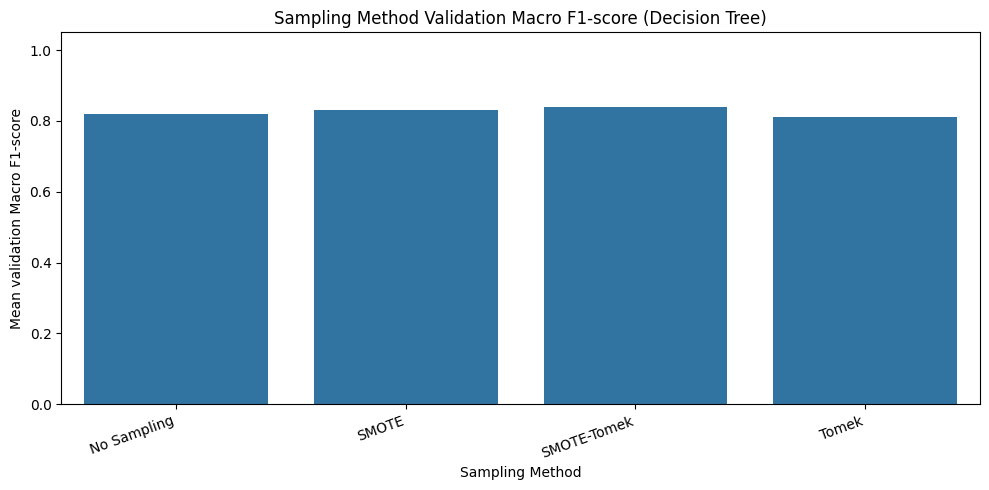

Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/06_sampling_method_validation.joblib
Sampling-method validation macro metrics:


,Sampling Method,Classifier Model,Log Loss,Macro Accuracy,Macro Precision,Macro Recall,Macro F1-score,Macro FPR,Macro ROC-AUC,Validation Folds
0,No Sampling,Decision Tree,0.0693,0.9992,0.8005,0.8809,0.8202,0.0005,0.9435,5
1,SMOTE,Decision Tree,0.0715,0.9991,0.8286,0.8841,0.8299,0.0005,0.9460,5
2,SMOTE-Tomek,Decision Tree,0.0690,0.9991,0.8385,0.8910,0.8383,0.0005,0.9499,5
3,Tomek,Decision Tree,0.0701,0.9993,0.7965,0.8643,0.8120,0.0004,0.9342,5


Sampling-method validation detailed per-class metrics:


,Sampling Method,Classifier Model,Class,Accuracy,Precision,Recall,F1-score,FPR,Support
0,No Sampling,Decision Tree,Benign,0.9988,0.9976,0.9958,0.9967,0.0006,68563
1,No Sampling,Decision Tree,Bot,0.9998,0.9647,0.9759,0.9702,0.0001,1367
2,No Sampling,Decision Tree,Brute Force,0.9981,0.9746,0.9325,0.9531,0.0005,7435
3,No Sampling,Decision Tree,DDoS,0.9993,0.9995,0.9994,0.9995,0.0008,225242
4,No Sampling,Decision Tree,Infiltrations,1.0000,0.9667,1.0000,0.9818,0.0000,25
5,No Sampling,Decision Tree,Port Scan,0.9996,0.9989,0.9989,0.9989,0.0002,63573
6,No Sampling,Decision Tree,SQL-Injection,0.9998,0.1395,0.4667,0.1905,0.0001,15
7,No Sampling,Decision Tree,XSS,0.9981,0.3623,0.6783,0.4711,0.0015,457
8,SMOTE,Decision Tree,Benign,0.9987,0.9980,0.9950,0.9965,0.0005,68563
9,SMOTE,Decision Tree,Bot,0.9996,0.9251,0.9839,0.9536,0.0003,1367


Selected sampling method: SMOTE-Tomek chosen by highest mean validation Macro F1-score. This method will be used for classifier validation.


In [14]:
# Validate sampling methods with Decision Tree and choose the best method by mean validation Macro F1-score
def stage_06_sampling_method_validation():
    if "fold_feature_cache" not in globals():
        restore_stage(
            "05_fold_feature_cache",
            expected_keys=["fold_feature_cache", "fold_feature_cache_summary"],
        )
    if "le" not in globals():
        restore_stage(
            "05_label_encoder", expected_keys=["le", "y_trainval_enc", "y_test_enc"]
        )

    sampling_validation_classifier = "Decision Tree"
    macro_rows = []
    per_class_rows = []
    distribution_rows = []

    for fold_cache in fold_feature_cache:
        fold = fold_cache["fold"]
        print(f"Sampling-method validation fold {fold}/{len(fold_feature_cache)}")
        X_fold_train_fs = fold_cache["X_train_fs"]
        X_fold_val_fs = fold_cache["X_val_fs"]
        y_fold_train = fold_cache["y_train"]
        y_fold_val = fold_cache["y_val"]
        y_fold_val_enc = le.transform(y_fold_val)

        for method_name in SAMPLING_METHOD_ORDER:
            append_distribution_rows(
                distribution_rows, fold, method_name, "Before Sampling", y_fold_train
            )
            X_resampled, y_resampled, _ = apply_sampling_method(
                method_name, X_fold_train_fs, y_fold_train
            )
            append_distribution_rows(
                distribution_rows, fold, method_name, "After Sampling", y_resampled
            )

            model = make_dt_classifier(random_state=RANDOM_STATE, profile="validation")
            model.fit(X_resampled, le.transform(y_resampled))

            context = {
                "Fold": fold,
                "Sampling Method": method_name,
                "Classifier Model": sampling_validation_classifier,
                "Validation Process": "Sampling Method",
            }
            macro_row, class_rows, _ = evaluate_model_metrics(
                context, model, X_fold_val_fs, y_fold_val_enc, le
            )
            macro_rows.append(macro_row)
            per_class_rows.extend(class_rows)

    sampling_method_validation_macro_by_fold = pd.DataFrame(macro_rows)
    sampling_method_validation_per_class_by_fold = pd.DataFrame(per_class_rows)
    sampling_method_validation_macro = summarize_macro_metrics(
        sampling_method_validation_macro_by_fold,
        ["Sampling Method", "Classifier Model"],
    )
    sampling_method_validation_per_class = summarize_per_class_metrics(
        sampling_method_validation_per_class_by_fold,
        ["Sampling Method", "Classifier Model"],
    )

    best_sampling_diagnostic_row = select_best_by_macro_f1(
        sampling_method_validation_macro, "Sampling Method", SAMPLING_METHOD_ORDER
    )
    best_sampling_diagnostic_method = best_sampling_diagnostic_row["Sampling Method"]
    best_sampling_diagnostic_table = pd.DataFrame([best_sampling_diagnostic_row])
    selected_sampling_method_table = best_sampling_diagnostic_table.copy()
    selected_sampling_method_table.insert(
        0, "Selection Role", "Selected Sampling Method"
    )

    sampling_distribution_by_fold = pd.DataFrame(distribution_rows)
    sampling_distribution_by_method = (
        sampling_distribution_by_fold.groupby(
            ["Sampling Method", "Stage", "Class"], dropna=False
        )
        .agg(
            {
                "Count": "mean",
                "Percentage": "mean",
                "Total Samples": "mean",
                "Fold": "nunique",
            }
        )
        .rename(columns={"Fold": "Validation Folds"})
        .reset_index()
    )

    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    sampling_method_validation_macro_by_fold.to_csv(
        RESULTS_DIR / "sampling_method_validation_macro_by_fold.csv", index=False
    )
    sampling_method_validation_per_class_by_fold.to_csv(
        RESULTS_DIR / "sampling_method_validation_per_class_by_fold.csv", index=False
    )
    sampling_method_validation_macro.to_csv(
        RESULTS_DIR / "sampling_method_validation_macro.csv", index=False
    )
    sampling_method_validation_per_class.to_csv(
        RESULTS_DIR / "sampling_method_validation_per_class.csv", index=False
    )
    best_sampling_diagnostic_table.to_csv(
        RESULTS_DIR / "best_sampling_diagnostic_method.csv", index=False
    )
    selected_sampling_method_table.to_csv(
        RESULTS_DIR / "selected_sampling_method.csv", index=False
    )
    sampling_distribution_by_fold.to_csv(
        RESULTS_DIR / "sampling_distribution_by_fold.csv", index=False
    )
    sampling_distribution_by_method.to_csv(
        RESULTS_DIR / "sampling_distribution_by_method.csv", index=False
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=sampling_method_validation_macro, x="Sampling Method", y="Macro F1-score"
    )
    plt.title("Sampling Method Validation Macro F1-score (Decision Tree)")
    plt.ylabel("Mean validation Macro F1-score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    sampling_method_plot_path = RESULTS_DIR / "sampling_method_validation_macro_f1.png"
    plt.savefig(sampling_method_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "sampling_method_validation_macro_by_fold": sampling_method_validation_macro_by_fold,
        "sampling_method_validation_per_class_by_fold": sampling_method_validation_per_class_by_fold,
        "sampling_method_validation_macro": sampling_method_validation_macro,
        "sampling_method_validation_per_class": sampling_method_validation_per_class,
        "best_sampling_diagnostic_method": best_sampling_diagnostic_method,
        "sampling_validation_classifier": sampling_validation_classifier,
        "best_sampling_diagnostic_table": best_sampling_diagnostic_table,
        "selected_sampling_method_table": selected_sampling_method_table,
        "sampling_distribution_by_fold": sampling_distribution_by_fold,
        "sampling_distribution_by_method": sampling_distribution_by_method,
        "sampling_method_plot_path": sampling_method_plot_path,
    }


run_or_load_stage(
    "06_sampling_method_validation",
    stage_06_sampling_method_validation,
    expected_keys=[
        "sampling_method_validation_macro",
        "sampling_method_validation_per_class",
        "best_sampling_diagnostic_method",
        "selected_sampling_method_table",
        "sampling_validation_classifier",
    ],
)

metric_format = {
    "Log Loss": "{:.4f}",
    "Macro Accuracy": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1-score": "{:.4f}",
    "Macro FPR": "{:.4f}",
    "Macro ROC-AUC": "{:.4f}",
}
class_format = {
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "FPR": "{:.4f}",
    "Support": "{:d}",
}

print("Sampling-method validation macro metrics:")
display(sampling_method_validation_macro.style.format(metric_format))
print("Sampling-method validation detailed per-class metrics:")
display(sampling_method_validation_per_class.style.format(class_format))
print(
    f"Selected sampling method: {best_sampling_diagnostic_method} "
    "chosen by highest mean validation Macro F1-score. This method will be used for classifier validation."
)

# Sampling Distribution Analysis


In [15]:
# Display average class distribution before and after each sampling method
if "sampling_distribution_by_method" not in globals():
    restore_stage(
        "06_sampling_method_validation",
        expected_keys=[
            "sampling_distribution_by_method",
            "best_sampling_diagnostic_method",
            "sampling_validation_classifier",
        ],
    )

print("Average class distribution across validation folds:")
display(
    sampling_distribution_by_method.style.format(
        {
            "Count": "{:.1f}",
            "Percentage": "{:.4f}",
            "Total Samples": "{:.1f}",
            "Validation Folds": "{:d}",
        }
    )
)
print(f"Sampling distribution files saved to: {RESULTS_DIR}")

Average class distribution across validation folds:


,Sampling Method,Stage,Class,Count,Percentage,Total Samples,Validation Folds
0,No Sampling,After Sampling,Benign,54850.4,18.6985,293341.6,5
1,No Sampling,After Sampling,Bot,1093.6,0.3728,293341.6,5
2,No Sampling,After Sampling,Brute Force,5948.0,2.0277,293341.6,5
3,No Sampling,After Sampling,DDoS,180193.6,61.4279,293341.6,5
4,No Sampling,After Sampling,Infiltrations,20.0,0.0068,293341.6,5
5,No Sampling,After Sampling,Port Scan,50858.4,17.3376,293341.6,5
6,No Sampling,After Sampling,SQL-Injection,12.0,0.0041,293341.6,5
7,No Sampling,After Sampling,XSS,365.6,0.1246,293341.6,5
8,No Sampling,Before Sampling,Benign,54850.4,18.6985,293341.6,5
9,No Sampling,Before Sampling,Bot,1093.6,0.3728,293341.6,5


Sampling distribution files saved to: /workspace/NIDS/pipeline/results_cv_full


# Model Validation Summary


Running stage: 07_classifier_validation
Classifier validation fold 1/5 using selected sampling method: SMOTE-Tomek
  Training Random Forest
  Training XGBoost
XGBoost device: cuda


/venv/main/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [09:37:18] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/venv/main/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


  Training KNN
  Training Decision Tree
  Training Logistic Regression


/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Training Stacking Ensemble


...

/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Training Stacking Ensemble


/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  Training Soft Voting Ensemble


/venv/main/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


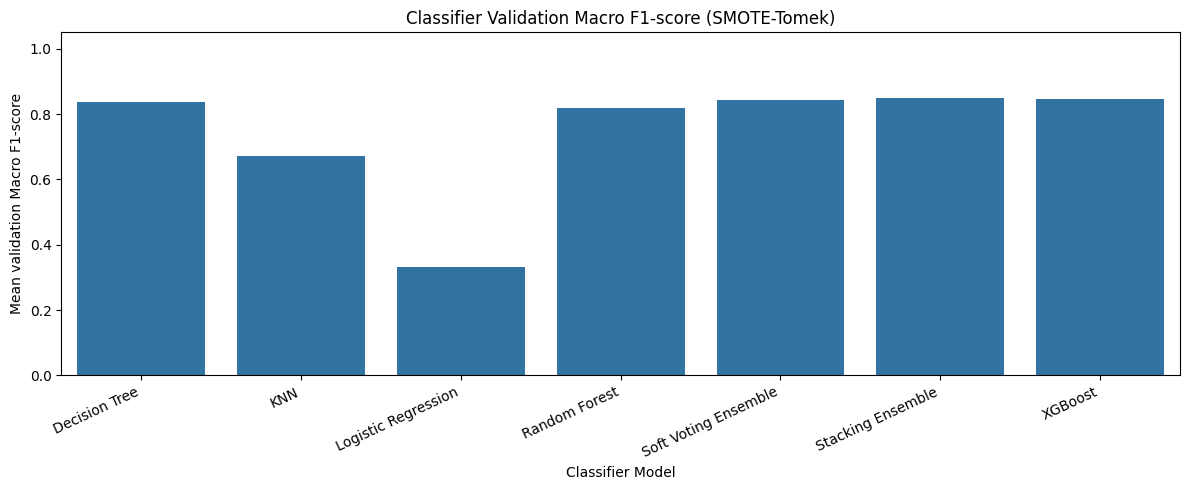

Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/07_classifier_validation.joblib
Classifier validation macro metrics using selected sampling method: SMOTE-Tomek


,Sampling Method,Classifier Model,Log Loss,Macro Accuracy,Macro Precision,Macro Recall,Macro F1-score,Macro FPR,Macro ROC-AUC,Validation Folds
0,SMOTE-Tomek,Decision Tree,0.0690,0.9991,0.8385,0.8910,0.8383,0.0005,0.9499,5
1,SMOTE-Tomek,KNN,0.3832,0.9961,0.6354,0.8068,0.6707,0.0027,0.9083,5
2,SMOTE-Tomek,Logistic Regression,0.8253,0.9297,0.3686,0.6592,0.3307,0.0441,0.9327,5
3,SMOTE-Tomek,Random Forest,0.0142,0.9992,0.8242,0.8460,0.8171,0.0005,0.9977,5
4,SMOTE-Tomek,Soft Voting Ensemble,0.0145,0.9993,0.8442,0.8767,0.8431,0.0004,0.9998,5
5,SMOTE-Tomek,Stacking Ensemble,0.0117,0.9993,0.8635,0.8720,0.8478,0.0004,0.9890,5
6,SMOTE-Tomek,XGBoost,0.0104,0.9991,0.8594,0.8927,0.8453,0.0005,0.9998,5


Selected-sampling classifier validation diagnostics:


,Sampling Method,Classifier Model,Log Loss,Macro F1-score,BF F1,BF Recall
0,SMOTE-Tomek,Decision Tree,0.0690,0.8383,0.948351,0.921453
1,SMOTE-Tomek,KNN,0.3832,0.6707,0.932328,0.921856
2,SMOTE-Tomek,Logistic Regression,0.8253,0.3307,0.491282,0.659180
3,SMOTE-Tomek,Random Forest,0.0142,0.8171,0.947817,0.915131
4,SMOTE-Tomek,Soft Voting Ensemble,0.0145,0.8431,0.950033,0.918359
5,SMOTE-Tomek,Stacking Ensemble,0.0117,0.8478,0.950553,0.923336
6,SMOTE-Tomek,XGBoost,0.0104,0.8453,0.940769,0.893073


Classifier validation detailed per-class metrics:


,Sampling Method,Classifier Model,Class,Accuracy,Precision,Recall,F1-score,FPR,Support
0,SMOTE-Tomek,Decision Tree,Benign,0.9988,0.9983,0.9951,0.9967,0.0004,68563
1,SMOTE-Tomek,Decision Tree,Bot,0.9996,0.9275,0.9824,0.9542,0.0003,1367
2,SMOTE-Tomek,Decision Tree,Brute Force,0.9980,0.9769,0.9215,0.9484,0.0005,7435
3,SMOTE-Tomek,Decision Tree,DDoS,0.9993,0.9995,0.9993,0.9994,0.0007,225242
4,SMOTE-Tomek,Decision Tree,Infiltrations,1.0000,0.9667,0.8800,0.8961,0.0000,25
5,SMOTE-Tomek,Decision Tree,Port Scan,0.9997,0.9990,0.9991,0.9991,0.0002,63573
6,SMOTE-Tomek,Decision Tree,SQL-Injection,0.9997,0.4910,0.6000,0.4370,0.0003,15
7,SMOTE-Tomek,Decision Tree,XSS,0.9979,0.3493,0.7505,0.4759,0.0018,457
8,SMOTE-Tomek,KNN,Benign,0.9871,0.9807,0.9500,0.9651,0.0043,68563
9,SMOTE-Tomek,KNN,Bot,0.9982,0.7016,0.9012,0.7887,0.0014,1367


Selected classifier model: Stacking Ensemble chosen by highest mean validation Macro F1-score. Final test will retrain this classifier.


In [16]:
# Validate classifier models with the selected sampling method and choose the best model by mean validation Macro F1-score
def stage_07_classifier_validation():
    if "fold_feature_cache" not in globals():
        restore_stage(
            "05_fold_feature_cache",
            expected_keys=["fold_feature_cache", "fold_feature_cache_summary"],
        )
    if "le" not in globals():
        restore_stage(
            "05_label_encoder", expected_keys=["le", "y_trainval_enc", "y_test_enc"]
        )
    if "best_sampling_diagnostic_method" not in globals():
        restore_stage(
            "06_sampling_method_validation",
            expected_keys=[
                "sampling_method_validation_macro",
                "sampling_method_validation_per_class",
                "best_sampling_diagnostic_method",
                "selected_sampling_method_table",
                "sampling_validation_classifier",
            ],
        )

    selected_classifier_sampling_method = best_sampling_diagnostic_method
    macro_rows = []
    per_class_rows = []

    for fold_cache in fold_feature_cache:
        fold = fold_cache["fold"]
        print(
            f"Classifier validation fold {fold}/{len(fold_feature_cache)} "
            f"using selected sampling method: {selected_classifier_sampling_method}"
        )
        X_fold_train_fs = fold_cache["X_train_fs"]
        X_fold_val_fs = fold_cache["X_val_fs"]
        y_fold_train = fold_cache["y_train"]
        y_fold_val = fold_cache["y_val"]

        X_resampled, y_resampled, _ = apply_sampling_method(
            selected_classifier_sampling_method, X_fold_train_fs, y_fold_train
        )
        y_resampled_enc = le.transform(y_resampled)
        y_fold_val_enc = le.transform(y_fold_val)

        for model_name in CLASSIFIER_MODEL_ORDER:
            print(f"  Training {model_name}")
            model = make_classifier_model(
                model_name, random_state=RANDOM_STATE, profile="validation"
            )
            model.fit(X_resampled, y_resampled_enc)

            context = {
                "Fold": fold,
                "Sampling Method": selected_classifier_sampling_method,
                "Classifier Model": model_name,
                "Validation Process": "Classifier Model",
            }
            macro_row, class_rows, _ = evaluate_model_metrics(
                context, model, X_fold_val_fs, y_fold_val_enc, le
            )
            macro_rows.append(macro_row)
            per_class_rows.extend(class_rows)

    classifier_validation_macro_by_fold = pd.DataFrame(macro_rows)
    classifier_validation_per_class_by_fold = pd.DataFrame(per_class_rows)
    classifier_validation_macro = summarize_macro_metrics(
        classifier_validation_macro_by_fold, ["Sampling Method", "Classifier Model"]
    )
    classifier_validation_per_class = summarize_per_class_metrics(
        classifier_validation_per_class_by_fold, ["Sampling Method", "Classifier Model"]
    )

    best_classifier_diagnostic_row = select_best_by_macro_f1(
        classifier_validation_macro, "Classifier Model", CLASSIFIER_MODEL_ORDER
    )
    best_classifier_diagnostic_model = best_classifier_diagnostic_row[
        "Classifier Model"
    ]
    best_classifier_diagnostic_table = pd.DataFrame([best_classifier_diagnostic_row])
    selected_classifier_table = best_classifier_diagnostic_table.copy()
    selected_classifier_table.insert(0, "Selection Role", "Selected Classifier Model")

    bf_validation = classifier_validation_per_class[
        classifier_validation_per_class["Class"] == "Brute Force"
    ][["Classifier Model", "F1-score", "Recall"]].rename(
        columns={"F1-score": "BF F1", "Recall": "BF Recall"}
    )
    selected_sampling_validation_diagnostics = classifier_validation_macro.merge(
        bf_validation, on="Classifier Model", how="left"
    )[
        [
            "Sampling Method",
            "Classifier Model",
            "Log Loss",
            "Macro F1-score",
            "BF F1",
            "BF Recall",
        ]
    ].reset_index(
        drop=True
    )

    classifier_validation_macro_by_fold.to_csv(
        RESULTS_DIR / "classifier_validation_macro_by_fold.csv", index=False
    )
    classifier_validation_per_class_by_fold.to_csv(
        RESULTS_DIR / "classifier_validation_per_class_by_fold.csv", index=False
    )
    classifier_validation_macro.to_csv(
        RESULTS_DIR / "classifier_validation_macro.csv", index=False
    )
    classifier_validation_per_class.to_csv(
        RESULTS_DIR / "classifier_validation_per_class.csv", index=False
    )
    best_classifier_diagnostic_table.to_csv(
        RESULTS_DIR / "best_classifier_diagnostic_model.csv", index=False
    )
    selected_classifier_table.to_csv(
        RESULTS_DIR / "selected_classifier_model.csv", index=False
    )
    selected_sampling_validation_diagnostics.to_csv(
        RESULTS_DIR / "selected_sampling_classifier_validation_diagnostics.csv",
        index=False,
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=classifier_validation_macro, x="Classifier Model", y="Macro F1-score"
    )
    plt.title(
        f"Classifier Validation Macro F1-score ({selected_classifier_sampling_method})"
    )
    plt.ylabel("Mean validation Macro F1-score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    classifier_validation_plot_path = RESULTS_DIR / "classifier_validation_macro_f1.png"
    plt.savefig(classifier_validation_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "classifier_validation_macro_by_fold": classifier_validation_macro_by_fold,
        "classifier_validation_per_class_by_fold": classifier_validation_per_class_by_fold,
        "classifier_validation_macro": classifier_validation_macro,
        "classifier_validation_per_class": classifier_validation_per_class,
        "best_classifier_diagnostic_model": best_classifier_diagnostic_model,
        "best_classifier_diagnostic_table": best_classifier_diagnostic_table,
        "selected_classifier_table": selected_classifier_table,
        "selected_classifier_sampling_method": selected_classifier_sampling_method,
        "selected_sampling_validation_diagnostics": selected_sampling_validation_diagnostics,
        "classifier_validation_plot_path": classifier_validation_plot_path,
    }


run_or_load_stage(
    "07_classifier_validation",
    stage_07_classifier_validation,
    expected_keys=[
        "classifier_validation_macro",
        "classifier_validation_per_class",
        "selected_sampling_validation_diagnostics",
        "best_classifier_diagnostic_model",
        "selected_classifier_sampling_method",
    ],
)

print(
    f"Classifier validation macro metrics using selected sampling method: {selected_classifier_sampling_method}"
)
display(classifier_validation_macro.style.format(metric_format))
print("Selected-sampling classifier validation diagnostics:")
display(selected_sampling_validation_diagnostics.style.format(metric_format))
print("Classifier validation detailed per-class metrics:")
display(classifier_validation_per_class.style.format(class_format))
print(
    f"Selected classifier model: {best_classifier_diagnostic_model} "
    "chosen by highest mean validation Macro F1-score. Final test will retrain this classifier."
)

# Final Test Evaluation


Running stage: 08_final_test_evaluation
Final model settings: {'rf_n_estimators': 300, 'rf_max_depth': 20, 'xgb_n_estimators': 300, 'xgb_max_depth': 8, 'dt_max_depth': 20, 'stacking_cv': 5}
Training selected final configuration: Stacking - SMOTE-Tomek


/venv/main/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


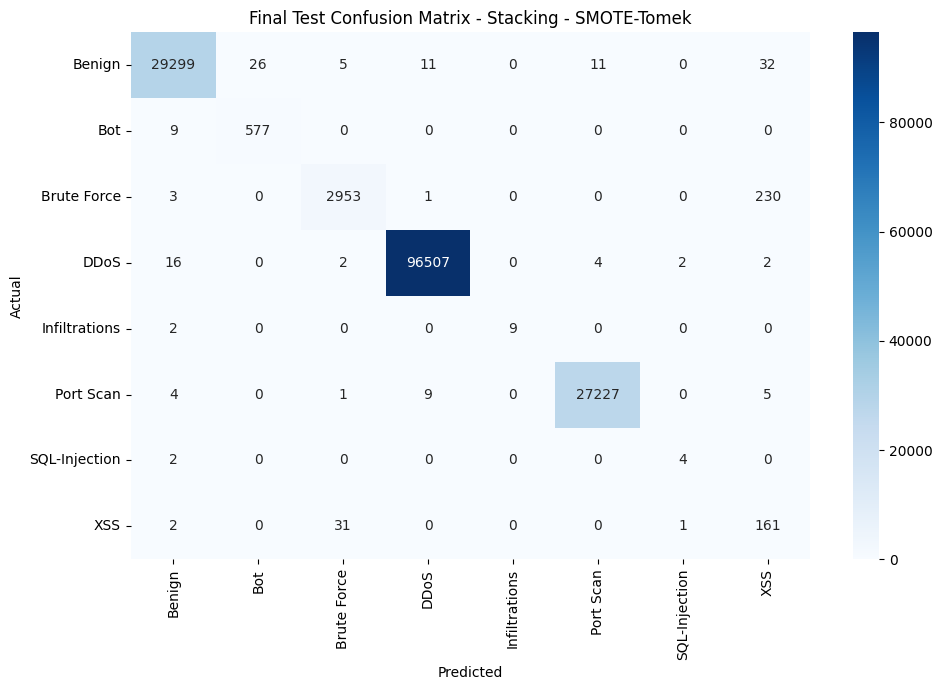

Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/08_final_test_evaluation.joblib
Final selected configuration for feature-importance follow-up:


,Run Mode,Selected Final Configuration,Selected Classifier Model,Selected Sampling Method,Selection Metric,Final Test Configurations,Final Train-Val Rows Before Sampling,Final Train-Val Rows After Sampling,Final Test Rows,Final Feature Count
0,full,Stacking - SMOTE-Tomek,Stacking Ensemble,SMOTE-Tomek,Highest validation Macro F1-score after select...,1,366677,762178,157148,16


Final test macro metrics:


,Split,Model,Sampling Method,Classifier Model,Final Train-Val Rows Before Sampling,Final Train-Val Rows After Sampling,Final Test Rows,Final Feature Count,Log Loss,Macro Accuracy,Macro Precision,Macro Recall,Macro F1-score,Macro FPR,Macro ROC-AUC
0,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,0.0116,0.9993,0.8610,0.9022,0.8693,0.0004,0.9798


Final test Brute Force metrics:


,Model,Sampling Method,Precision,Recall,F1-score,FPR,Support
0,Stacking,SMOTE-Tomek,0.9870,0.9266,0.9558,0.0003,3187


Final test detailed per-class metrics:


,Split,Model,Sampling Method,Classifier Model,Final Train-Val Rows Before Sampling,Final Train-Val Rows After Sampling,Final Test Rows,Final Feature Count,Class,Accuracy,Precision,Recall,F1-score,FPR,Support
0,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,Benign,0.9992,0.9987,0.9971,0.9979,0.0003,29384
1,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,Bot,0.9998,0.9569,0.9846,0.9706,0.0002,586
2,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,Brute Force,0.9983,0.9870,0.9266,0.9558,0.0003,3187
3,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,DDoS,0.9997,0.9998,0.9997,0.9998,0.0003,96533
4,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,Infiltrations,1.0000,1.0000,0.8182,0.9000,0.0000,11
5,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,Port Scan,0.9998,0.9994,0.9993,0.9994,0.0001,27246
6,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,SQL-Injection,1.0000,0.5714,0.6667,0.6154,0.0000,6
7,Final Test,Stacking,SMOTE-Tomek,Stacking Ensemble,366677,762178,157148,16,XSS,0.9981,0.3744,0.8256,0.5152,0.0017,195


Final test files saved to: /workspace/NIDS/pipeline/results_cv_full


In [17]:
# Retrain the selected classifier on the full 70% training-validation pool and evaluate once on the untouched 30% test set
def _final_model_label(model_name):
    return model_name.replace(" Ensemble", "")


def stage_08_final_test_evaluation():
    if "X_trainval" not in globals() or "X_test" not in globals():
        restore_stage(
            "04_stratified_split",
            expected_keys=["X_trainval", "X_test", "y_trainval", "y_test", "cv_splits"],
        )
    if "le" not in globals():
        restore_stage(
            "05_label_encoder", expected_keys=["le", "y_trainval_enc", "y_test_enc"]
        )
    if (
        "best_classifier_diagnostic_model" not in globals()
        or "selected_classifier_sampling_method" not in globals()
    ):
        restore_stage(
            "07_classifier_validation",
            expected_keys=[
                "classifier_validation_macro",
                "classifier_validation_per_class",
                "selected_sampling_validation_diagnostics",
                "best_classifier_diagnostic_model",
                "selected_classifier_sampling_method",
            ],
        )

    final_feature_steps = fit_feature_steps(X_trainval, y_trainval)
    X_trainval_fs = apply_feature_steps(X_trainval, final_feature_steps)
    X_test_fs = apply_feature_steps(X_test, final_feature_steps)

    final_model_name = best_classifier_diagnostic_model
    final_sampling_method = selected_classifier_sampling_method
    model_label = _final_model_label(final_model_name)
    final_model_key = f"{model_label} - {final_sampling_method}"

    print(f"Final model settings: {RUN_CONFIG['final_models']}")
    print(f"Training selected final configuration: {final_model_key}")

    X_final_train, y_final_train, sampling_info = apply_sampling_method(
        final_sampling_method, X_trainval_fs, y_trainval
    )
    y_final_train_enc = le.transform(y_final_train)

    final_model = make_classifier_model(
        final_model_name, random_state=RANDOM_STATE, profile="final"
    )
    final_model.fit(X_final_train, y_final_train_enc)

    context = {
        "Split": "Final Test",
        "Model": model_label,
        "Sampling Method": final_sampling_method,
        "Classifier Model": final_model_name,
        "Final Train-Val Rows Before Sampling": len(X_trainval_fs),
        "Final Train-Val Rows After Sampling": len(X_final_train),
        "Final Test Rows": len(X_test_fs),
        "Final Feature Count": X_trainval_fs.shape[1],
    }
    macro_row, class_rows, final_cm = evaluate_model_metrics(
        context, final_model, X_test_fs, y_test_enc, le
    )

    final_test_macro_metrics = pd.DataFrame([macro_row])
    final_test_per_class_metrics = pd.DataFrame(class_rows)
    final_models = {final_model_key: final_model}
    final_sampling_info_by_config = {final_model_key: sampling_info}

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        final_cm,
        annot=True,
        fmt="d",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cmap="Blues",
    )
    plt.title(f"Final Test Confusion Matrix - {final_model_key}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    safe_key = final_model_key.lower().replace(" ", "_").replace("-", "minus")
    final_confusion_matrix_plot_path = (
        RESULTS_DIR / f"final_test_confusion_matrix_{safe_key}.png"
    )
    plt.savefig(final_confusion_matrix_plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    final_confusion_matrix_plot_paths = {
        final_model_key: final_confusion_matrix_plot_path
    }

    final_selected_configuration = pd.DataFrame(
        [
            {
                "Run Mode": RUN_MODE,
                "Selected Final Configuration": final_model_key,
                "Selected Classifier Model": final_model_name,
                "Selected Sampling Method": final_sampling_method,
                "Selection Metric": "Highest validation Macro F1-score after selected sampling method",
                "Final Test Configurations": len(final_test_macro_metrics),
                "Final Train-Val Rows Before Sampling": len(X_trainval_fs),
                "Final Train-Val Rows After Sampling": len(X_final_train),
                "Final Test Rows": len(X_test_fs),
                "Final Feature Count": X_trainval_fs.shape[1],
            }
        ]
    )

    final_brute_force_test_metrics = final_test_per_class_metrics[
        final_test_per_class_metrics["Class"] == "Brute Force"
    ][
        [
            "Model",
            "Sampling Method",
            "Precision",
            "Recall",
            "F1-score",
            "FPR",
            "Support",
        ]
    ].reset_index(
        drop=True
    )

    final_test_macro_metrics.to_csv(
        RESULTS_DIR / "final_test_macro_metrics.csv", index=False
    )
    final_test_per_class_metrics.to_csv(
        RESULTS_DIR / "final_test_per_class_metrics.csv", index=False
    )
    final_selected_configuration.to_csv(
        RESULTS_DIR / "final_selected_configuration.csv", index=False
    )
    final_brute_force_test_metrics.to_csv(
        RESULTS_DIR / "final_brute_force_test_metrics.csv", index=False
    )

    return {
        "final_feature_steps": final_feature_steps,
        "X_trainval_fs": X_trainval_fs,
        "X_test_fs": X_test_fs,
        "final_models": final_models,
        "final_model": final_model,
        "final_model_key": final_model_key,
        "final_test_macro_metrics": final_test_macro_metrics,
        "final_test_per_class_metrics": final_test_per_class_metrics,
        "final_brute_force_test_metrics": final_brute_force_test_metrics,
        "final_confusion_matrix_plot_paths": final_confusion_matrix_plot_paths,
        "final_selected_configuration": final_selected_configuration,
        "final_sampling_info_by_config": final_sampling_info_by_config,
    }


run_or_load_stage(
    "08_final_test_evaluation",
    stage_08_final_test_evaluation,
    expected_keys=[
        "final_model",
        "final_test_macro_metrics",
        "final_test_per_class_metrics",
        "final_selected_configuration",
    ],
)

print("Final selected configuration for feature-importance follow-up:")
display(final_selected_configuration)
print("Final test macro metrics:")
display(final_test_macro_metrics.style.format(metric_format))
print("Final test Brute Force metrics:")
display(final_brute_force_test_metrics.style.format(class_format))
print("Final test detailed per-class metrics:")
display(final_test_per_class_metrics.style.format(class_format))
print(f"Final test files saved to: {RESULTS_DIR}")

# Feature Importance Analysis


Running stage: 09_feature_importance
Computing permutation importance on 50,000 test samples with 3 repeats.


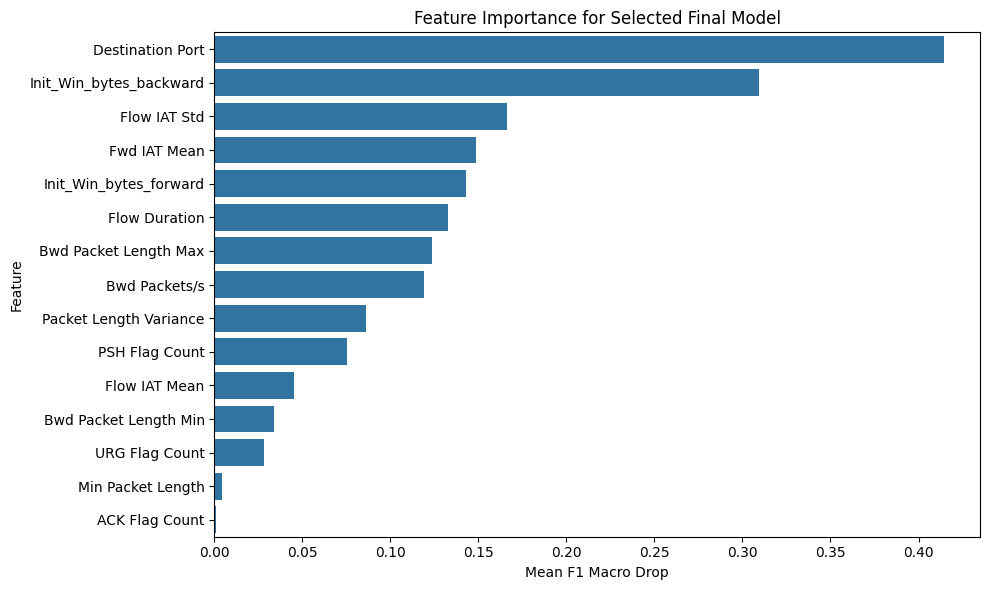

Checkpoint saved: /workspace/NIDS/pipeline/pipeline_full_checkpoints/09_feature_importance.joblib
Feature importance for selected final model:


,Feature,ANOVA F-score,ANOVA p-value,Dropped by Correlation Pruning,Permutation Importance Mean,Permutation Importance Std,Importance Rank
0,Destination Port,9588.0823,0.0000e+00,False,0.414226,0.019992,1
1,Init_Win_bytes_backward,4333.3940,0.0000e+00,False,0.309650,0.020597,2
2,Flow IAT Std,20375.2983,0.0000e+00,False,0.166045,0.011232,3
3,Fwd IAT Mean,9107.7783,0.0000e+00,False,0.148884,0.025062,4
4,Init_Win_bytes_forward,9194.7971,0.0000e+00,False,0.142790,0.006052,5
5,Flow Duration,17679.7355,0.0000e+00,False,0.132461,0.006943,6
6,Bwd Packet Length Max,39609.1056,0.0000e+00,False,0.123877,0.057969,7
7,Bwd Packets/s,6565.5207,0.0000e+00,False,0.118872,0.002984,8
8,Packet Length Variance,19953.3509,0.0000e+00,False,0.086303,0.019073,9
9,PSH Flag Count,25397.5511,0.0000e+00,False,0.075584,0.000177,10


Feature importance files saved to: /workspace/NIDS/pipeline/results_cv_full


In [18]:
# Feature importance for the selected final model
RUN_FEATURE_IMPORTANCE = RUN_CONFIG["run_feature_importance"]
FEATURE_IMPORTANCE_MAX_SAMPLES = RUN_CONFIG["feature_importance_max_samples"]
FEATURE_IMPORTANCE_N_REPEATS = RUN_CONFIG["feature_importance_n_repeats"]


def stage_09_feature_importance():
    if not RUN_FEATURE_IMPORTANCE:
        feature_importance_selected_model = pd.DataFrame(
            columns=[
                "Feature",
                "ANOVA F-score",
                "ANOVA p-value",
                "Dropped by Correlation Pruning",
                "Permutation Importance Mean",
                "Permutation Importance Std",
                "Importance Rank",
            ]
        )
        feature_importance_selected_model.to_csv(
            RESULTS_DIR / "feature_importance_selected_model.csv", index=False
        )
        print(
            "Feature importance skipped for this run mode. "
            "Set RUN_MODE='full' or RUN_CONFIG['run_feature_importance']=True to enable it."
        )
        return {
            "feature_importance_selected_model": feature_importance_selected_model,
            "feature_importance_plot_path": None,
            "feature_importance_skipped": True,
        }

    if "final_model" not in globals() or "final_feature_steps" not in globals():
        restore_stage(
            "08_final_test_evaluation",
            expected_keys=[
                "final_model",
                "final_feature_steps",
                "X_test_fs",
                "final_test_macro_metrics",
            ],
        )
    if "le" not in globals() or "y_test_enc" not in globals():
        restore_stage(
            "05_label_encoder", expected_keys=["le", "y_trainval_enc", "y_test_enc"]
        )

    selector = final_feature_steps["selector"]
    final_cols = final_feature_steps["final_cols"]
    input_cols = selector.feature_names_in_
    score_lookup = pd.Series(selector.scores_, index=input_cols)
    pvalue_lookup = pd.Series(selector.pvalues_, index=input_cols)

    feature_importance_selected_model = pd.DataFrame(
        {
            "Feature": final_cols,
            "ANOVA F-score": [
                score_lookup.get(feature, np.nan) for feature in final_cols
            ],
            "ANOVA p-value": [
                pvalue_lookup.get(feature, np.nan) for feature in final_cols
            ],
            "Dropped by Correlation Pruning": [
                feature in final_feature_steps["to_drop"] for feature in final_cols
            ],
        }
    )

    if len(X_test_fs) > FEATURE_IMPORTANCE_MAX_SAMPLES:
        X_importance_sample, _, y_importance_sample, _ = train_test_split(
            X_test_fs,
            y_test_enc,
            train_size=FEATURE_IMPORTANCE_MAX_SAMPLES,
            stratify=y_test_enc,
            random_state=RANDOM_STATE,
        )
    else:
        X_importance_sample = X_test_fs
        y_importance_sample = y_test_enc

    print(
        f"Computing permutation importance on {len(X_importance_sample):,} test samples "
        f"with {FEATURE_IMPORTANCE_N_REPEATS} repeats."
    )
    permutation_result = permutation_importance(
        final_model,
        X_importance_sample,
        y_importance_sample,
        scoring="f1_macro",
        n_repeats=FEATURE_IMPORTANCE_N_REPEATS,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

    permutation_table = pd.DataFrame(
        {
            "Feature": X_test_fs.columns,
            "Permutation Importance Mean": permutation_result.importances_mean,
            "Permutation Importance Std": permutation_result.importances_std,
        }
    )

    feature_importance_selected_model = (
        feature_importance_selected_model.merge(
            permutation_table, on="Feature", how="left"
        )
        .sort_values("Permutation Importance Mean", ascending=False)
        .reset_index(drop=True)
    )
    feature_importance_selected_model["Importance Rank"] = np.arange(
        1, len(feature_importance_selected_model) + 1
    )

    feature_importance_selected_model.to_csv(
        RESULTS_DIR / "feature_importance_selected_model.csv", index=False
    )

    plt.figure(figsize=(10, 6))
    top_features = feature_importance_selected_model.head(15)
    sns.barplot(data=top_features, y="Feature", x="Permutation Importance Mean")
    plt.title("Feature Importance for Selected Final Model")
    plt.xlabel("Mean F1 Macro Drop")
    plt.ylabel("Feature")
    plt.tight_layout()
    feature_importance_plot_path = RESULTS_DIR / "feature_importance_selected_model.png"
    plt.savefig(feature_importance_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "feature_importance_selected_model": feature_importance_selected_model,
        "feature_importance_plot_path": feature_importance_plot_path,
        "feature_importance_skipped": False,
    }


run_or_load_stage(
    "09_feature_importance",
    stage_09_feature_importance,
    expected_keys=["feature_importance_selected_model"],
)

if feature_importance_selected_model.empty:
    print("Feature importance table is empty because feature importance was skipped.")
else:
    print("Feature importance for selected final model:")
    display(
        feature_importance_selected_model.style.format(
            {
                "ANOVA F-score": "{:.4f}",
                "ANOVA p-value": "{:.4e}",
                "Permutation Importance Mean": "{:.6f}",
                "Permutation Importance Std": "{:.6f}",
                "Importance Rank": "{:d}",
            }
        )
    )
print(f"Feature importance files saved to: {RESULTS_DIR}")